## Model Invoking

-------------ChatOllama-------------
Why don't scientists trust atoms?

Because they make up everything! 😄

Want to hear another one, or are you in the mood for a different style of humor?
-------------init_chat_model-------------
Here's one for you:

Why don't scientists trust atoms?

Because they make up everything! 😄

Want to hear another one, or is there a specific type of humor you're into?


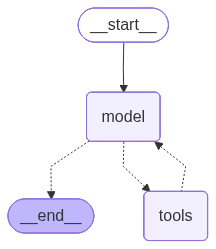

In [55]:
from langchain_ollama import ChatOllama
from langchain.chat_models import init_chat_model


model = ChatOllama(model="minimax-m3:cloud", temperature=0.5, num_predict=100)
model1 = init_chat_model(model="ollama:minimax-m3:cloud", temperature=0.5, num_predict=100)

print("-------------ChatOllama-------------")
print(model.invoke("Tell a joke").content)
print("-------------init_chat_model-------------")
print(model1.invoke("Tell a joke").content)


from langchain.agents import create_agent

def add_numbers(a:int, b:int) -> int:
    """Add two numbers provided by the user"""
    return a+b

agent = create_agent(
    model="ollama:gemma4:31b-cloud",
    tools=[add_numbers],
    system_prompt="You are a helpful assistant."
)
agent

## Streaming

In [12]:
from langchain.chat_models import init_chat_model

model = init_chat_model("ollama:minimax-m3:cloud")

for chunck in model.stream("In 200 words generate a para about Apple the fruit"):
    print(chunck.content, end="", flush=True) # flush is for live update in terminal

Apples are among the world's most beloved and widely consumed fruits, belonging to the rose family, Rosaceae, and scientifically classified under the genus Malus. Originating in Central Asia, particularly in the region of modern-day Kazakhstan, apples have been cultivated for thousands of years, with over 7,500 known varieties existing today. They come in an array of colors, including red, green, yellow, and even pink, each offering distinct flavors ranging from sweet to tart. Nutritionally, apples are a powerhouse of essential vitamins, minerals, and dietary fiber, particularly pectin, which supports digestive health. Rich in antioxidants like quercetin and vitamin C, apples contribute to heart health, help regulate blood sugar levels, and may reduce the risk of chronic diseases. The popular saying, "an apple a day keeps the doctor away," reflects their long-standing reputation for promoting wellness. Beyond their health benefits, apples play a significant role in culinary traditions 

## Batching

In [13]:
from langchain.chat_models import init_chat_model

model = init_chat_model("ollama:minimax-m3:cloud")

response = model.batch([
    "Count 1 to 10",
    "Count 11 to 20",
    "Count 21 to 30"
])

for res in response:
    print(res.content)

1, 2, 3, 4, 5, 6, 7, 8, 9, 10.
11, 12, 13, 14, 15, 16, 17, 18, 19, 20.
21, 22, 23, 24, 25, 26, 27, 28, 29, 30.


## Tools

In [60]:
from langchain.tools import tool


@tool
def get_weather(location: str) -> str:
    """Gets the current weather conditions for a specific city or location."""
    return f"It's sunny in {location}"


from langchain.chat_models import init_chat_model

model = init_chat_model("ollama:minimax-m3:cloud")
model_with_tools = model.bind_tools(tools=[get_weather])
response = model_with_tools.invoke("what is the weather in Chennai")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

response

Tool: get_weather
Args: {'location': 'Chennai'}


AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-17T06:45:55.458561806Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3653642150, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 53, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed454-3e77-76d3-8a7e-870f7dbc559c-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Chennai'}, 'id': '6b8b487f-5f73-4d8e-b5f4-5698329b9df2', 'type': 'tool_call'}], invalid_tool_calls=[])

## Tool Exection Loops

In [58]:
messages = [{"role":"user", "content":"What's the weather in Chennai?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

final_response = model_with_tools.invoke(messages)
print(final_response.text)

It's currently sunny in Chennai. ☀️

If you'd like, I can also check the weather in other cities—just let me know!


In [59]:
messages

[{'role': 'user', 'content': "What's the weather in Chennai?"},
 AIMessage(content="I'll check the current weather conditions for Chennai.", additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-17T06:38:37.419233209Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2949816336, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 77, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed44d-9384-7c90-b5a9-81c65b271ef7-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Chennai'}, 'id': 'd2ed92ed-4bb6-4ad0-ba75-964bdd9327a1', 'type': 'tool_call'}], invalid_tool_calls=[]),
 ToolMessage(content="It's sunny in Chennai", name='get_weather', tool_call_id='d2ed92ed-4bb6-4ad0-ba75-964bdd9327a1')]

## Messages

In [9]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.chat_models import init_chat_model

model = init_chat_model(model="ollama:qwen3.5:9b")

messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage(
        content="Hi",
        name="Arun",
        id="msg_123"
    ),
    AIMessage("Hello, Arun!"),
    HumanMessage("What is 2+2")

]

response = model.invoke(messages)
response

AIMessage(content='2 + 2 equals 4.', additional_kwargs={}, response_metadata={'model': 'qwen3.5:9b', 'created_at': '2026-06-17T08:23:04.2814171Z', 'done': True, 'done_reason': 'stop', 'total_duration': 114966327800, 'load_duration': 19602979800, 'prompt_eval_count': 42, 'prompt_eval_duration': 3098558000, 'eval_count': 407, 'eval_duration': 92201420000, 'logprobs': None, 'model_name': 'qwen3.5:9b', 'model_provider': 'ollama'}, id='lc_run--019ed4ab-7e42-7082-82be-0d97cfdadd50-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 407, 'total_tokens': 449})

## Structured Output

### Pydantic

In [52]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

model = init_chat_model(model="ollama:gemma4:31b-cloud")

class Actor(BaseModel):
    name:str
    role:str

class Movie(BaseModel):
    """Details of a Movie"""
    title:str = Field(description="The title of the movie")
    year:int = Field(description="The year when the movie was released")
    one_line_plot:str = Field(description="One line plot of the movie")
    genres:list[str] = Field(description="The list of genre of the movie")
    rating:float = Field(description="The rating of the movie out of 10")
    cast: list[Actor]

parser = PydanticOutputParser(pydantic_object=Movie)

prompt = PromptTemplate(
    template="Answer the user query.\n{format_instructions}\n{query}\n",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

chain = prompt | model | parser

result = chain.invoke({"query": "Tell me about Inception"})
result

Movie(title='Inception', year=2010, one_line_plot='A thief who steals corporate secrets through the use of dream-sharing technology is given the inverse task of planting an idea into the mind of a C.E.O.', genres=['Action', 'Sci-Fi', 'Adventure'], rating=8.8, cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Elliot Page', role='Ariadne'), Actor(name='Ken Watanabe', role='Saito'), Actor(name='Marion Cotillard', role='Mal')])

In [79]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent

class Actor(BaseModel):
    name:str
    role:str

class Movie(BaseModel):
    """Details of a Movie"""
    title:str = Field(description="The title of the movie")
    year:int = Field(description="The year when the movie was released")
    one_line_plot:str = Field(description="One line plot of the movie")
    genres:list[str] = Field(description="The list of genre of the movie")
    rating:float = Field(description="The rating of the movie out of 10")
    cast: list[Actor]

agent = create_agent(
    model="ollama:minimax-m3:cloud",
    response_format=Movie # Auto-selects provider strategry
) 

result = agent.invoke({
    "messages": [{"role":"user", "content":"Tell me about Interstellar"}]
})

result

{'messages': [HumanMessage(content='Tell me about Interstellar', additional_kwargs={}, response_metadata={}, id='da08c2b0-dcf9-491b-a167-360721f1f6c0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-17T15:26:01.842041416Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4329601205, 'load_duration': None, 'prompt_eval_count': 576, 'prompt_eval_duration': None, 'eval_count': 310, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed630-6b9d-7981-afe1-9bde72e2e714-0', tool_calls=[{'name': 'Movie', 'args': {'title': 'Interstellar', 'year': 2014, 'one_line_plot': "A team of explorers travel through a wormhole in space in an attempt to ensure humanity's survival.", 'genres': ['Science Fiction', 'Drama', 'Adventure'], 'rating': 8.6, 'cast': [{'name': 'Matthew McConaughey', 'role': 'Cooper'}, {'name': 'Anne Hathaway', 'role': 'Dr. Amelia Brand'}, {'name': 'Jess

### TypedDict
Unlike pydantic this doesn't provide runtime validation, it uses python's built-in typing

In [34]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from typing_extensions import TypedDict, Annotated

class LaptopDict(TypedDict):
    name: Annotated[str, "Name of the laptop"]
    brand: Annotated[str, "Brand of the laptop"]
    year: Annotated[int, "The year when the laptop was launched"]
    price: Annotated[float, "Price of the laptop"]

model = init_chat_model(model="ollama:gemma4:31b-cloud", temperature=0)

structured_model = model.with_structured_output(LaptopDict)

prompt = PromptTemplate.from_template("""
    You are a strict data extraction bot. 
    You must output ONLY a valid JSON object. 
    Do not include any introductory sentences, conversational text, or markdown blocks.

    Query: {query}
""")

chain = prompt | structured_model

response = chain.invoke({"query": "Tell me about Mackbook air m1"})
response

{'product': 'MacBook Air M1',
 'chip': 'Apple M1',
 'form_factor': 'Laptop',
 'key_features': ['Fanless design',
  'Apple Silicon integration',
  'Long battery life',
  'Retina display']}

In [75]:
from typing import Optional
from typing_extensions import TypedDict, Annotated
from langchain.agents import create_agent

class LaptopDict(TypedDict):
    name: Annotated[Optional[str], "Name of the laptop"]
    brand: Annotated[Optional[str], "Brand of the laptop"]
    year: Annotated[Optional[int], "The year when the laptop was launched"]
    price: Annotated[Optional[float], "Price of the laptop"]

agent = create_agent(
    model="ollama:minimax-m3:cloud",
    response_format=LaptopDict # Auto-selects provider strategry
) 

result = agent.invoke({
    "messages": 
        [{
            "role":"system", 
            "content": "You must extract laptop details into the requested JSON format. If the laptop does not exist or you are unsure about the details, set all unknown fields in the JSON to null."
        }, 
        {
            "role":"user", 
            "content":"Tell me about Macbook Air M10"
        }]
})

result

{'messages': [SystemMessage(content='You must extract laptop details into the requested JSON format. If the laptop does not exist or you are unsure about the details, set all unknown fields in the JSON to null.', additional_kwargs={}, response_metadata={}, id='d44e228c-70bf-4e71-9c08-007ceaa4910a'),
  HumanMessage(content='Tell me about Macbook Air M10', additional_kwargs={}, response_metadata={}, id='1d06a445-5383-4f60-8ac0-0debfd6e81e7'),
  AIMessage(content='The MacBook Air M10 does not exist. Apple has released MacBook Air models with M1, M2, M3, and M4 chips, but never an "M10" chip. You may be thinking of one of these existing models:\n\n- **MacBook Air M1** (2020)\n- **MacBook Air M2** (2022/2023)\n- **MacBook Air M3** (2024)\n- **MacBook Air M4** (2025)\n\nSince the requested laptop does not exist, here is the JSON with all fields set to null:', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-17T15:20:18.290983709Z', 'done': True, 'done_re

In [38]:
model_with_structure.profile

AttributeError: 'RunnableSequence' object has no attribute 'profile'

In [ ]:
model = init_chat_model(model="ollama:qwen3.5:9b")
model.profile # cmd -> ollama show qwen3.5:9b

## DataClasses

In [80]:
from langchain.agents import create_agent
from dataclasses import dataclass

@dataclass
class ContactInfo:
    """Contact information for a person"""
    name: str
    email: str
    phone: str

agent = create_agent(
    model="ollama:minimax-m3:cloud",
    response_format=ContactInfo
)

agent.invoke({
    "messages": [{"role":"user", "content":"Extract contact info from this: There lived a person named David Billa, he had a fancy email david@billa.com, his mobile number was 9876543210 "}]
})

{'messages': [HumanMessage(content='Extract contact info from this: There lived a person named David Billa, he had a fancy email david@billa.com, his mobile number was 9876543210 ', additional_kwargs={}, response_metadata={}, id='611be3b3-a4e9-4b74-964f-31851976bea6'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-17T15:32:04.921349189Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3789031833, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 101, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed635-f41e-7c91-ac28-816131ae71c3-0', tool_calls=[{'name': 'ContactInfo', 'args': {'name': 'David Billa', 'email': 'david@billa.com', 'phone': '9876543210'}, 'id': 'e57572a8-39b9-4ee9-8d89-67a2c4f9ca27', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content="Returning structured response: ContactInf

## Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
1. Tracking agent behavior with logging, analytics, and debugging.
2. Transforming prompts, tool selection, and output formatting.
3.  Adding retries, fallbacks, and early termination logic.
4. Applying rate limits, guardrails, and PII detection.

### Summarization Middleware

Summarization Middlware work based on following parameters
1. fraction (float): Fraction of model’s context size (0-1)
2. tokens (int): Absolute token count
3. messages (int): Message count

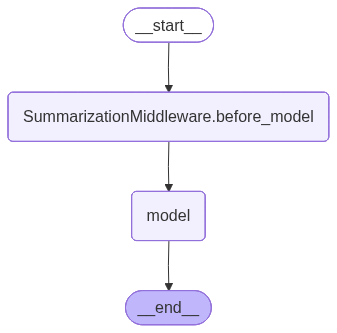

In [98]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="ollama:minimax-m3:cloud",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="ollama:minimax-m3:cloud",
            trigger=("messages",6),
            keep=("messages", 3)
        )
    ]
)

agent

In [99]:
config = {"configurable": {"thread_id":"test-1"}}

questions = [
    "What is 1+1",
    "What is 2+2",
    "What is 3+3",
    "What is 4+4",
    "What is 5+5",
    "What is 6+6",
    "What is 7+7",
    "What is 8+8",
    "What is 9+9",
    "What is 10+10",
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config=config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response["messages"])}")

Messages: {'messages': [HumanMessage(content='What is 1+1', additional_kwargs={}, response_metadata={}, id='3d117f87-1849-4ac2-aa48-57dafdd2e1c3'), AIMessage(content='1 + 1 = 2', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-18T06:40:31.095388861Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3214694232, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 24, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed975-a9b7-76f1-9689-df0f3b208339-0', tool_calls=[], invalid_tool_calls=[])]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 1+1', additional_kwargs={}, response_metadata={}, id='3d117f87-1849-4ac2-aa48-57dafdd2e1c3'), AIMessage(content='1 + 1 = 2', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-18T06:40:31.095388861Z', 'done': True, 'done_reason': 'stop', 'total_durati

### Human In The Loop Middleware

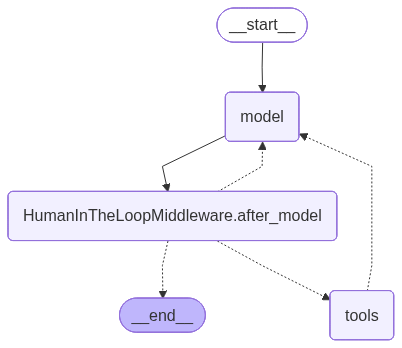

In [118]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware, ToolCallRequest
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"


def is_ending_with_gmail(request: ToolCallRequest) -> bool:
    """Check if email ends with gmail.com"""
    to_email = request.tool_call["args"].get("recipient", "")
    return not to_email.endswith("@gmail.com")

agent = create_agent(
    model="ollama:minimax-m3:cloud",
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                    "when": is_ending_with_gmail # When predicate returns False, call runs without interupting
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

agent

#### Case where sending email to @billa.com requires human in the loop

In [126]:
config = {"configurable": {"thread_id":"test-david-billa"}}

result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "send a short greeting email to david@billa.com"}
        ]
    }, 
    config=config
)

result

{'messages': [HumanMessage(content='send a short greeting email to david@billa.com', additional_kwargs={}, response_metadata={}, id='9c5ea8d0-d362-4f04-b3a4-a5a604066f7e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-18T08:17:17.20983936Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2508034070, 'load_duration': None, 'prompt_eval_count': 495, 'prompt_eval_duration': None, 'eval_count': 124, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed9ce-4220-7f71-a9de-05cbb86db1f9-0', tool_calls=[{'name': 'your_send_email_tool', 'args': {'recipient': 'david@billa.com', 'subject': 'Hello from a friend!', 'body': "Hi David,\n\nHope you're doing well! Just wanted to send a quick hello and wish you a great day.\n\nBest wishes!"}, 'id': '548ba9e0-c79a-4db4-9065-fba6563e2e48', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 495, '

In [128]:
from langgraph.types import Command

result = agent.invoke(
    Command(
        resume={
            "decisions": [{"type": "approve"}]
        }
    ),
    config=config # Same thread ID to resume the paused conversation
)

result

{'messages': [HumanMessage(content='send a short greeting email to david@billa.com', additional_kwargs={}, response_metadata={}, id='9c5ea8d0-d362-4f04-b3a4-a5a604066f7e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-18T08:17:17.20983936Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2508034070, 'load_duration': None, 'prompt_eval_count': 495, 'prompt_eval_duration': None, 'eval_count': 124, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed9ce-4220-7f71-a9de-05cbb86db1f9-0', tool_calls=[{'name': 'your_send_email_tool', 'args': {'recipient': 'david@billa.com', 'subject': 'Hello from a friend!', 'body': "Hi David,\n\nHope you're doing well! Just wanted to send a quick hello and wish you a great day.\n\nBest wishes!"}, 'id': '548ba9e0-c79a-4db4-9065-fba6563e2e48', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 495, '

#### case where sending email to user with @gmail.com

In [121]:
config = {"configurable": {"thread_id":"test-gmail"}}

result = agent.invoke({
    "messages": [
        {"role": "user", "content": "send a short greeting email to arun@gmail.com"}
    ]
}, config=config)

result

{'messages': [HumanMessage(content='send a short greeting email to arun@gmail.com', additional_kwargs={}, response_metadata={}, id='ec2776cd-2f49-4970-8bc8-943bc73bcdc5'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-18T08:02:22.000294578Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2625254808, 'load_duration': None, 'prompt_eval_count': 495, 'prompt_eval_duration': None, 'eval_count': 116, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'}, id='lc_run--019ed9c0-9bf3-7741-98a0-96cf17c2a126-0', tool_calls=[{'name': 'your_send_email_tool', 'args': {'recipient': 'arun@gmail.com', 'subject': 'Hello from a friend!', 'body': "Hi Arun,\n\nHope you're doing well! Just wanted to send a quick hello and wish you a great day ahead.\n\nTake care!\nBest regards"}, 'id': 'be194182-59e6-42b4-af88-908a35c6802a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input